In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Cargar el dataset
df = pd.read_csv("partidos_cebollitas.csv")

In [2]:
# Crear nuevas variables que ayudarán al modelo
df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
df['diferencia_posesion'] = df['posesion_local (%)'] - df['posesion_visitante (%)']
df['eficiencia_tiros_local'] = df['goles_local'] / (df['tiros_arco_local'] + 1e-5)
df['eficiencia_tiros_visitante'] = df['goles_visitante'] / (df['tiros_arco_visitante'] + 1e-5)
df['local_es_cebollitas'] = (df['equipo_local'] == 'Cebollitas FC').astype(int)
df = pd.get_dummies(df, columns=['estadio'], drop_first=True)

display(df.head())

,fecha_partido,equipo_local,equipo_visitante,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,diferencia_goles,diferencia_posesion,eficiencia_tiros_local,eficiencia_tiros_visitante,local_es_cebollitas,estadio_Estadio DataCamp,estadio_Estadio ML,estadio_Python Arena
0,2023-01-01,Atlético Python,Cebollitas FC,2,0,54,46,12,6,2,8,0.166667,0.000000,0,False,False,True
1,2023-01-08,NumPy City,Atlético Python,1,5,60,40,12,3,-4,20,0.083333,1.666661,0,False,True,False
2,2023-01-15,Cebollitas FC,Data United,1,0,55,45,10,7,1,10,0.100000,0.000000,1,False,False,True
3,2023-01-22,Atlético Python,Data United,2,3,57,43,3,3,-1,14,0.666664,0.999997,0,False,False,False
4,2023-01-29,Data United,Cebollitas FC,5,3,52,48,7,12,2,4,0.714285,0.250000,0,False,True,False


In [3]:
# Elegimos las variables más informativas
features = [
    'posesion_local (%)', 'tiros_arco_local', 'diferencia_posesion',
    'eficiencia_tiros_local', 'eficiencia_tiros_visitante',
    'local_es_cebollitas'
] + [col for col in df.columns if col.startswith("estadio_")]

X = df[features]
y = df['diferencia_goles']

In [4]:
# Separar en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Entrenamos el modelo Random Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Hacer predicciones
y_pred_rf = modelo_rf.predict(X_test)

In [6]:
# Métricas de evaluación
from sklearn.metrics import mean_absolute_error


rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"📊 RMSE: {rmse_rf:.2f}")
print(f"📉 MAE: {mae_rf:.2f}")
print(f"📈 R²: {r2_rf:.2f}")

📊 RMSE: 1.02
📉 MAE: 0.73
📈 R²: 0.78


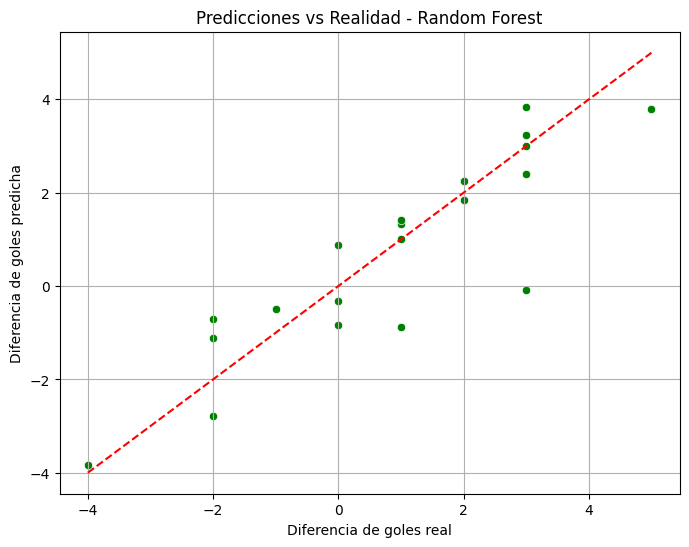

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Diferencia de goles real")
plt.ylabel("Diferencia de goles predicha")
plt.title("Predicciones vs Realidad - Random Forest")
plt.grid(True)
plt.show()